"""
Import et nettoyage du dataset "Medical Appointment No Shows" (Kaggle)
vers une base MySQL structurée (tables patients + rendez_vous).
 
Prérequis :
    pip install pandas sqlalchemy pymysql
 
Avant d'exécuter ce script :
    1. Télécharge le CSV depuis https://www.kaggle.com/datasets/joniarroba/noshowappointments
    2. Place-le dans data/raw/ (ex: data/raw/KaggleV2-May-2016.csv)
    3. Crée la base et les tables avec sql/01_create_schema.sql
    4. Renseigne tes identifiants MySQL ci-dessous (ou via variables d'environnement)
"""

In [2]:
pip install pandas sqlalchemy pymysql


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine

## 1. Configuration

In [4]:
CSV_PATH = r"D:\PROJETS\Projet 1\clinic-noshow-prediction\data\raw\KaggleV2-May-2016.csv"

db_user = os.getenv("db_user", "root")
db_password = os.getenv("db_password", "NouveauMotDePasse123!")
db_host = os.getenv("db_host", "localhost")
db_name = os.getenv("db_name", "clinic_noshow")

ENGINE_URL = f"mysql+pymysql://{db_user}:{db_password}@{db_host}/{db_name}"

## 2. Lecture du csv

In [5]:
def load_raw_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"Fichier chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    return df

## 3. Nettoyage

In [6]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

     # Renommage des colonnes (fautes de frappe d'origine + cohérence snake_case)
    df = df.rename(columns={
        "PatientId": "patient_id",
        "AppointmentID": "appointment_id",
        "Gender": "sexe",
        "ScheduledDay": "date_prise_rdv",
        "AppointmentDay": "date_consultation",
        "Age": "age",
        "Neighbourhood": "quartier",
        "Scholarship": "boursier",
        "Hipertension": "hypertension",
        "Diabetes": "diabete",
        "Alcoholism": "alcoolisme",
        "Handcap": "handicap",
        "SMS_received": "sms_recu",
        "No-show": "no_show_raw",
    })

     # Types entier pour les ID et datetime pour les textes date
    df["patient_id"] = df["patient_id"].astype("int64")
    df["appointment_id"] = df["appointment_id"].astype("int64")
    df["date_prise_rdv"] = pd.to_datetime(df["date_prise_rdv"])
    df["date_consultation"] = pd.to_datetime(df["date_consultation"])

     # Cible : No-show = 'Yes' veut dire absent -> on veut presence = 1 si présent
    df["presence"] = (df["no_show_raw"] == "No").astype(int)
    df = df.drop(columns = ["no_show_raw"])

     # Ages négatifs ou aberrants : on supprime les lignes invalides
    before = len(df)
    df = df[(df["age"] >= 0) & (df["age"] <= 115)]
    removed = before - len(df)
    if removed:
        print(f"{removed} lignes supprimées (âge invalide)")

    # Handicap : dataset source a des valeurs 0-4, on binarise pour simplifier 
    # (on veut juste savoir qui est handicapé pas le niveau de handicap. Juste pour simplifier)
    df["handicap"] = (df["handicap"] > 0).astype(int)

    # Booléens
    for col in ["boursier", "hypertension", "diabete", "alcoolisme", "sms_recu"]:
        df[col] = df[col].astype(int)
 
    # Jour de la semaine de la consultation
    df["jour_semaine"] = df["date_consultation"].dt.day_name()
 
    # Délai entre prise de RDV et consultation (en jours)
    df["delai_jours"] = (df["date_consultation"].dt.normalize()
                          - df["date_prise_rdv"].dt.normalize()).dt.days
    # Quelques lignes ont un délai négatif (erreur de saisie d'origine) -> on les met à 0
    df.loc[df["delai_jours"] < 0, "delai_jours"] = 0
 
    print(f"Après nettoyage : {df.shape[0]} lignes")
    return df

## 4. Normalisation

In [7]:
def build_patients_table(df: pd.DataFrame) -> pd.DataFrame:
    patients = (
        df[["patient_id", "age", "sexe", "quartier", "hypertension", 
            "diabete", "alcoolisme", "handicap"]]
        .drop_duplicates(subset= "patient_id", keep = "first") 
        .reset_index(drop = True)   
    )
    return patients

def build_rendez_vous_table(df: pd.DataFrame) -> pd.DataFrame:
    rdv = df[[
        "appointment_id", "patient_id", "date_prise_rdv", "date_consultation",
        "jour_semaine", "sms_recu", "presence", "delai_jours", "boursier"
    ]].reset_index(drop = True)
    return rdv

## 5. Insertion dans la base de données

In [8]:
def insert_to_mysql(patients: pd.DataFrame, rdv: pd.DataFrame, ENGINE_URL: str):
    engine = create_engine(ENGINE_URL)
 
    # if_exists="append" car les tables sont déjà créées via le script SQL
    # (structure, clés primaires/étrangères, types) -> on ne laisse pas
    # pandas les recréer avec des types approximatifs.
    patients.to_sql("patients", engine, if_exists="append", index=False, chunksize=5000)
    print(f"{len(patients)} patients insérés")
 
    rdv.to_sql("rendez_vous", engine, if_exists="append", index=False, chunksize=5000)
    print(f"{len(rdv)} rendez-vous insérés")

## 6. Exécution

In [9]:
df_raw = load_raw_data(CSV_PATH)
df_clean = clean_data(df_raw)

    

Fichier chargé : 110527 lignes, 14 colonnes
1 lignes supprimées (âge invalide)
Après nettoyage : 110526 lignes


In [10]:
patients = build_patients_table(df_clean)
rdv = build_rendez_vous_table(df_clean)
insert_to_mysql(patients, rdv, ENGINE_URL)

DatabaseError: Execution failed on sql 'INSERT INTO patients (patient_id, age, sexe, quartier, hypertension, diabete, alcoolisme, handicap) VALUES (:patient_id, :age, :sexe, :quartier, :hypertension, :diabete, :alcoolisme, :handicap)': (pymysql.err.IntegrityError) (1062, "Duplicate entry '29872499824296' for key 'patients.PRIMARY'")
[SQL: INSERT INTO patients (patient_id, age, sexe, quartier, hypertension, diabete, alcoolisme, handicap) VALUES (%(patient_id)s, %(age)s, %(sexe)s, %(quartier)s, %(hypertension)s, %(diabete)s, %(alcoolisme)s, %(handicap)s)]
[parameters: [{'patient_id': 29872499824296, 'age': 62, 'sexe': 'F', 'quartier': 'JARDIM DA PENHA', 'hypertension': 1, 'diabete': 0, 'alcoolisme': 0, 'handicap': 0}, {'patient_id': 558997776694438, 'age': 56, 'sexe': 'M', 'quartier': 'JARDIM DA PENHA', 'hypertension': 0, 'diabete': 0, 'alcoolisme': 0, 'handicap': 0}, {'patient_id': 4262962299951, 'age': 62, 'sexe': 'F', 'quartier': 'MATA DA PRAIA', 'hypertension': 0, 'diabete': 0, 'alco

In [18]:
df_clean = add_historique_absences(df_clean)

In [17]:
def add_historique_absences(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["patient_id", "date_consultation"]).copy()

    # Nombre de rdv précédents pour ce patient
    df["nb_rdv_precedents"] = df.groupby("patient_id").cumcount()

    #Somme cumulées des présences, en excluant le rdv actuel
    presence_cumulee = df.groupby("patient_id")["presence"].cumsum() - df["presence"]
    # Taux de présence historique = présences passées / nb de RDV passés
    df["taux_presence_historique"] = presence_cumulee / df["nb_rdv_precedents"]

    # Flag pour repérer les patients à leur premier RDV (pas d'historique)
    df["premier_rdv"] = (df["nb_rdv_precedents"] == 0).astype(int)

    # Imputation : pour les premiers RDV, on utilise le taux de présence moyen global
    taux_moyen_global = df["presence"].mean()
    df["taux_presence_historique"] = df["taux_presence_historique"].fillna(taux_moyen_global)

    return df

In [ ]:
df_clean = add_historique_absences(df_clean)

In [ ]:
df_clean.head()

,patient_id,appointment_id,sexe,date_prise_rdv,date_consultation,age,quartier,boursier,hypertension,diabete,alcoolisme,handicap,sms_recu,presence,jour_semaine,delai_jours,nb_rdv_precedents,taux_presence_historique,premier_rdv
100517,39217,5751990,F,2016-05-31 10:56:41+00:00,2016-06-03 00:00:00+00:00,44,PRAIA DO SUÁ,0,0,0,0,0,0,1,Friday,3,0,0.798066,1
105430,43741,5760144,M,2016-06-01 14:22:58+00:00,2016-06-01 00:00:00+00:00,39,MARIA ORTIZ,0,0,1,0,0,0,1,Wednesday,0,0,0.798066,1
3950,93779,5712759,F,2016-05-18 09:12:29+00:00,2016-05-18 00:00:00+00:00,33,CENTRO,0,0,0,0,0,0,1,Wednesday,0,0,0.798066,1
73303,141724,5637648,M,2016-04-29 07:13:36+00:00,2016-05-02 00:00:00+00:00,12,FORTE SÃO JOÃO,0,0,0,0,0,0,1,Monday,3,0,0.798066,1
73228,537615,5637728,F,2016-04-29 07:19:57+00:00,2016-05-06 00:00:00+00:00,14,FORTE SÃO JOÃO,0,0,0,0,0,1,1,Friday,7,0,0.798066,1


In [19]:
df_clean[["patient_id", "date_consultation", "presence", "nb_rdv_precedents", "taux_presence_historique", "premier_rdv"]].head(15)

,patient_id,date_consultation,presence,nb_rdv_precedents,taux_presence_historique,premier_rdv
100517,39217,2016-06-03 00:00:00+00:00,1,0,0.798066,1
105430,43741,2016-06-01 00:00:00+00:00,1,0,0.798066,1
3950,93779,2016-05-18 00:00:00+00:00,1,0,0.798066,1
73303,141724,2016-05-02 00:00:00+00:00,1,0,0.798066,1
73228,537615,2016-05-06 00:00:00+00:00,1,0,0.798066,1
54611,5628261,2016-05-13 00:00:00+00:00,0,0,0.798066,1
40692,11831856,2016-05-19 00:00:00+00:00,1,0,0.798066,1
58616,22638656,2016-05-03 00:00:00+00:00,1,0,0.798066,1
88585,22638656,2016-06-08 00:00:00+00:00,1,1,1.000000,0
83628,52168938,2016-05-16 00:00:00+00:00,1,0,0.798066,1


In [20]:
df_clean.columns

Index(['patient_id', 'appointment_id', 'sexe', 'date_prise_rdv',
       'date_consultation', 'age', 'quartier', 'boursier', 'hypertension',
       'diabete', 'alcoolisme', 'handicap', 'sms_recu', 'presence',
       'jour_semaine', 'delai_jours', 'nb_rdv_precedents',
       'taux_presence_historique', 'premier_rdv'],
      dtype='str')

In [21]:
# Encodage des varaibles 
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Encodage du sexe (1 = Femme, 0 = Homme)
    df["sexe_encoded"] = (df["sexe"] == "F").astype(int)

    # Jour de la semaine en numérique (0 = Lundi ... 6 = Dimanche)
    jours_ordre = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
        "Friday": 4, "Saturday": 5, "Sunday": 6
    }
    df["jour_semaine_num"] = df["jour_semaine"].map(jours_ordre)

    # Tranche d'âge (cohérent avec l'analyse SQL faite précédemment)
    def tranche_age(age):
        if age < 12:
            return 0  # enfant
        elif age < 18:
            return 1  # ado
        elif age < 40:
            return 2  # jeune adulte
        elif age < 65:
            return 3  # adulte
        else:
            return 4  # senior

    df["tranche_age"] = df["age"].apply(tranche_age)

    return df

In [22]:
df_clean = add_historique_absences(df_clean)
df_clean = add_features(df_clean)

In [23]:
df_clean[["age", "tranche_age", "sexe", "sexe_encoded", "jour_semaine", "jour_semaine_num"]].head(10)

,age,tranche_age,sexe,sexe_encoded,jour_semaine,jour_semaine_num
100517,44,3,F,1,Friday,4
105430,39,2,M,0,Wednesday,2
3950,33,2,F,1,Wednesday,2
73303,12,1,M,0,Monday,0
73228,14,1,F,1,Friday,4
54611,13,1,M,0,Friday,4
40692,16,1,M,0,Thursday,3
58616,22,2,F,1,Tuesday,1
88585,23,2,F,1,Wednesday,2
83628,28,2,F,1,Monday,0


In [24]:
features_modele = [
    "age", "tranche_age", "sexe_encoded",
    "hypertension", "diabete", "alcoolisme", "handicap",
    "boursier", "sms_recu",
    "delai_jours", "jour_semaine_num",
    "nb_rdv_precedents", "taux_presence_historique", "premier_rdv"
]

target = "presence"

df_model = df_clean[features_modele + [target]].copy()

In [25]:
df_model.isnull().sum()

age                         0
tranche_age                 0
sexe_encoded                0
hypertension                0
diabete                     0
alcoolisme                  0
handicap                    0
boursier                    0
sms_recu                    0
delai_jours                 0
jour_semaine_num            0
nb_rdv_precedents           0
taux_presence_historique    0
premier_rdv                 0
presence                    0
dtype: int64

In [26]:
# Entrainement
from sklearn.model_selection import train_test_split

X = df_model[features_modele]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # préserve la même proportion de no-show dans train et test
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test : {X_test.shape[0]} lignes")
print(f"Taux de présence train : {y_train.mean():.3f}")
print(f"Taux de présence test : {y_test.mean():.3f}")

Train : 88420 lignes
Test : 22106 lignes
Taux de présence train : 0.798
Taux de présence test : 0.798


In [27]:
# Regression logistqiue
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La régression logistique est sensible à l'échelle des variables
# (contrairement à Random Forest/XGBoost), donc on standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred, target_names=["Absent", "Présent"]))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print(f"\nROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

      Absent       0.32      0.58      0.41      4464
     Présent       0.87      0.68      0.76     17642

    accuracy                           0.66     22106
   macro avg       0.59      0.63      0.59     22106
weighted avg       0.75      0.66      0.69     22106


Matrice de confusion :
[[ 2605  1859]
 [ 5633 12009]]

ROC-AUC : 0.675


In [29]:
# Regression logistique
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # utilise tous les cœurs disponibles pour accélérer l'entraînement
)

# Pas besoin de standardisation pour Random Forest (insensible à l'échelle des variables)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["Absent", "Présent"]))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC-AUC : {roc_auc_score(y_test, y_proba_rf):.3f}")

              precision    recall  f1-score   support

      Absent       0.31      0.80      0.45      4464
     Présent       0.92      0.55      0.69     17642

    accuracy                           0.60     22106
   macro avg       0.61      0.68      0.57     22106
weighted avg       0.79      0.60      0.64     22106


Matrice de confusion :
[[3585  879]
 [7921 9721]]

ROC-AUC : 0.738


In [30]:
importances = pd.DataFrame({
    "feature": features_modele,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                     feature  importance
9                delai_jours    0.658230
0                        age    0.080523
12  taux_presence_historique    0.078720
8                   sms_recu    0.051995
11         nb_rdv_precedents    0.035557
1                tranche_age    0.027672
10          jour_semaine_num    0.021794
2               sexe_encoded    0.009786
3               hypertension    0.007537
7                   boursier    0.007097
13               premier_rdv    0.006238
5                 alcoolisme    0.005083
4                    diabete    0.004959
6                   handicap    0.004811


In [31]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [32]:
from xgboost import XGBClassifier

# scale_pos_weight : équivalent de class_weight="balanced" pour XGBoost
# Se calcule comme (nb de négatifs / nb de positifs) sur le train
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=["Absent", "Présent"]))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.3f}")

              precision    recall  f1-score   support

      Absent       0.31      0.79      0.45      4464
     Présent       0.91      0.56      0.69     17642

    accuracy                           0.60     22106
   macro avg       0.61      0.67      0.57     22106
weighted avg       0.79      0.60      0.64     22106


Matrice de confusion :
[[3520  944]
 [7824 9818]]

ROC-AUC : 0.737


In [33]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [34]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

c:\Users\User\anaconda3\envs\GorfEnvironnement\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


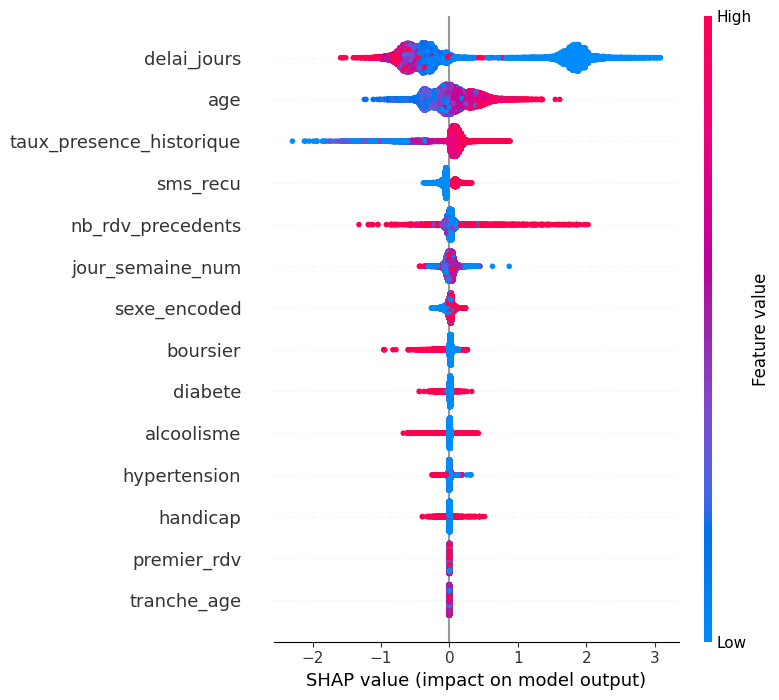

In [35]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, feature_names=features_modele, show=False)
plt.show()

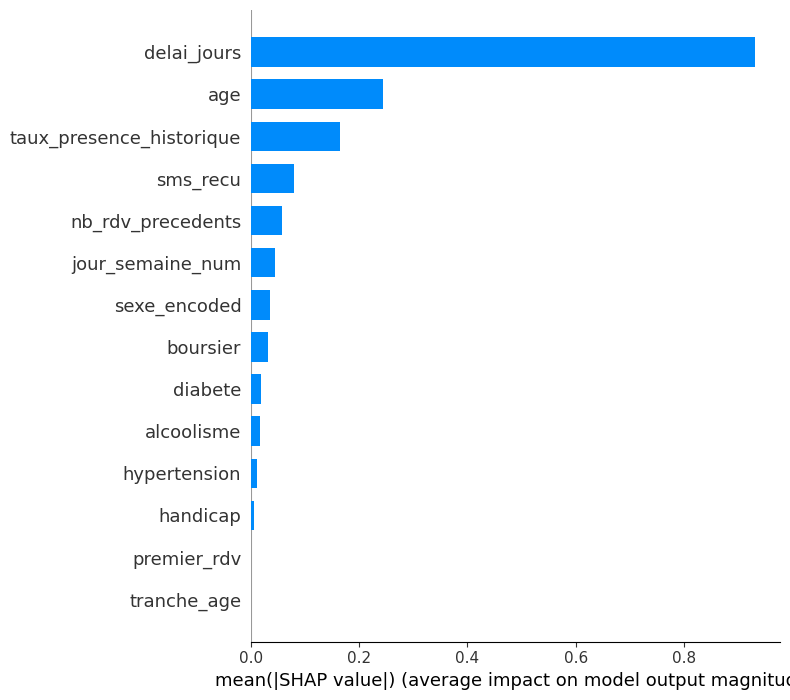

In [36]:
shap.summary_plot(shap_values, X_test, feature_names=features_modele, plot_type="bar")

In [37]:
features_clustering = [
    "age", "sexe_encoded",
    "hypertension", "diabete", "alcoolisme", "handicap",
    "boursier", "sms_recu",
    "delai_jours", "jour_semaine_num",
    "nb_rdv_precedents", "taux_presence_historique"
]

X_cluster = df_clean[features_clustering].copy()

In [14]:
df_clean.columns

Index(['patient_id', 'appointment_id', 'sexe', 'date_prise_rdv',
       'date_consultation', 'age', 'quartier', 'boursier', 'hypertension',
       'diabete', 'alcoolisme', 'handicap', 'sms_recu', 'presence',
       'jour_semaine', 'delai_jours'],
      dtype='str')

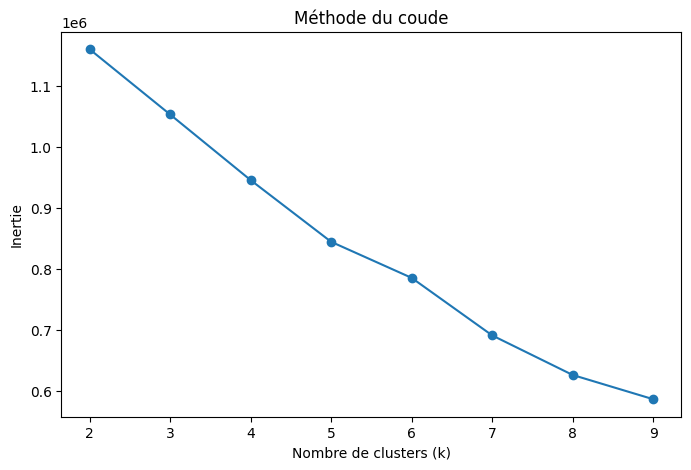

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()

In [39]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels, sample_size=10000, random_state=42)
    print(f"k={k} : silhouette = {score:.3f}")

k=2 : silhouette = 0.248
k=3 : silhouette = 0.161
k=4 : silhouette = 0.181
k=5 : silhouette = 0.199
k=6 : silhouette = 0.219
k=7 : silhouette = 0.247


In [40]:
features_clustering_v2 = [
    "age", "delai_jours", "nb_rdv_precedents", "taux_presence_historique"
]

X_cluster_v2 = df_clean[features_clustering_v2].copy()

scaler_cluster_v2 = StandardScaler()
X_cluster_v2_scaled = scaler_cluster_v2.fit_transform(X_cluster_v2)

k=2 : inertie = 360321, silhouette = 0.262
k=3 : inertie = 284073, silhouette = 0.308
k=4 : inertie = 210818, silhouette = 0.323
k=5 : inertie = 153070, silhouette = 0.359
k=6 : inertie = 136425, silhouette = 0.356
k=7 : inertie = 122716, silhouette = 0.365


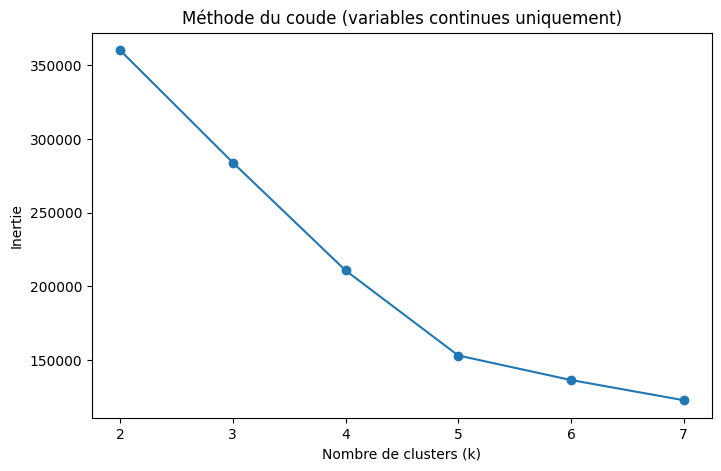

In [41]:
inertias_v2 = []
silhouettes_v2 = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_v2_scaled)
    inertias_v2.append(km.inertia_)
    score = silhouette_score(X_cluster_v2_scaled, labels, sample_size=10000, random_state=42)
    silhouettes_v2.append(score)
    print(f"k={k} : inertie = {km.inertia_:.0f}, silhouette = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias_v2, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude (variables continues uniquement)")
plt.show()

In [42]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["cluster"] = kmeans_final.fit_predict(X_cluster_v2_scaled)

df_clean["cluster"].value_counts().sort_index()

cluster
0    15084
1    43481
2      830
3     6852
4    44279
Name: count, dtype: int64

In [43]:
cluster_profile = df_clean.groupby("cluster").agg(
    taille=("cluster", "size"),
    age_moyen=("age", "mean"),
    delai_moyen=("delai_jours", "mean"),
    nb_rdv_precedents_moyen=("nb_rdv_precedents", "mean"),
    taux_presence_historique_moyen=("taux_presence_historique", "mean"),
    taux_presence_reel=("presence", "mean")
).round(2)

print(cluster_profile)

         taille  age_moyen  delai_moyen  nb_rdv_precedents_moyen  \
cluster                                                            
0         15084      38.05        39.99                     0.56   
1         43481      57.29         4.99                     1.17   
2           830      47.05         1.11                    37.98   
3          6852      34.64         9.92                     1.80   
4         44279      17.12         5.34                     0.84   

         taux_presence_historique_moyen  taux_presence_reel  
cluster                                                      
0                                  0.83                0.69  
1                                  0.85                0.85  
2                                  0.97                0.95  
3                                  0.05                0.64  
4                                  0.85                0.81  


In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_v2_scaled)

print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum():.2%}")

Variance expliquée par les 2 composantes : 53.93%


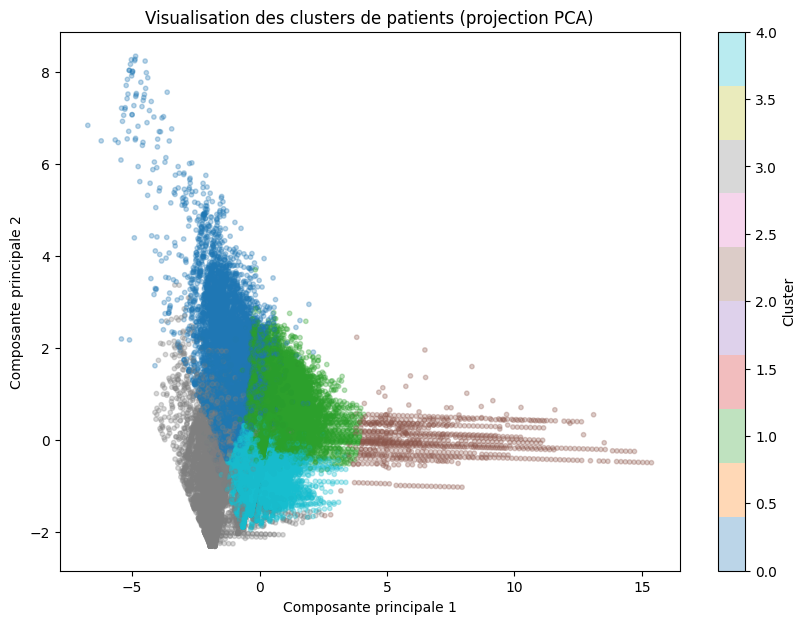

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_clean["cluster"],
    cmap="tab10",
    alpha=0.3,
    s=10
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Visualisation des clusters de patients (projection PCA)")
plt.colorbar(scatter, label="Cluster")
plt.show()